### Part I

### Estimating Parameters for a Uniform Distribution

We are given $X_1, \dots, X_n \sim \text{Unif}(a, b)$, where $a$ and $b$ are unknown parameters and $a < b$.

**Statistical Model and Parameter Identifiability**
*   **Statistical Model:** The statistical model for a uniform distribution $\text{Unif}(a,b)$ is given by $(\mathbb{R}, \{\text{Unif}[a, b]\}_{a < b})$. The probability density function (PDF) is $f(x; (a, b)) = \frac{1}{b - a} \cdot \mathbf{1}_{[a, b]}(x)$.
*   **Parameter Identifiability:** The parameters $a$ and $b$ are identifiable, meaning different pairs of $(a, b)$ lead to distinct probability distributions.

We perform the following tasks:

1.  **Method of Moments (MoM) for estimating $a$ and $b$**
    *   First moment: $E[X] = \frac{a+b}{2}$
    *   Second moment: $E[X^2] = \frac{(b-a)^2}{12} + \left(\frac{a+b}{2}\right)^2 = \frac{a^2 + ab + b^2}{3}$
    *   Sample moments:
        *   $M_1 = \frac{1}{n} \sum_{i=1}^{n} X_i$
        *   $M_2 = \frac{1}{n} \sum_{i=1}^{n} X_i^2$
    *   Solving for $\hat{a}$ and $\hat{b}$ (MoM estimators):
        *   $M_1 = \frac{\hat{a} + \hat{b}}{2} \Rightarrow \hat{a} + \hat{b} = 2M_1$
        *   $M_2 = \frac{\hat{a}^2 + \hat{a}\hat{b} + \hat{b}^2}{3} \Rightarrow \hat{a}^2 + \hat{a}\hat{b} + \hat{b}^2 = 3M_2$
        *   Resulting estimators:
            *   $\hat{a} = M_1 - \sqrt{3(M_1^2 - M_2)}$
            *   $\hat{b} = M_1 + \sqrt{3(M_1^2 - M_2)}$
        *   *Note: For finite samples, it's possible for the term $3(M_1^2 - M_2)$ to be negative, leading to complex solutions or estimators outside the parameter space.*

2.  **Maximum Likelihood Estimators (MLE) for $a$ and $b$**
    *   Density function: $f(x; (a, b)) = \begin{cases} \frac{1}{b - a} & \text{for } a \le x \le b \\ 0 & \text{otherwise} \end{cases}$
    *   Likelihood function: $L_n(a, b) = \prod_{i=1}^{n} f(X_i; (a, b)) = \begin{cases} (b - a)^{-n} & \text{for } a \le X_i \le b \text{ for all } X_i \\ 0 & \text{otherwise} \end{cases}$
    *   To maximize the likelihood, we need to maximize $(b-a)^{-n}$, which is equivalent to minimizing $(b-a)$, subject to $a \le X_{(1)}$ and $X_{(n)}\le b$.
    *   Resulting MLE estimators:
        *   $\hat{a}_{MLE} = \min\{X_1, \dots, X_n\} = X_{(1)}$
        *   $\hat{b}_{MLE} = \max\{X_1, \dots, X_n\} = X_{(n)}$

3.  **Maximum Likelihood Estimator of $\tau = E[X]$**
    *   We know $\tau = E[X] = \frac{a+b}{2}$.
    *   Using the invariance property of MLEs, the MLE of $\tau$ is $\hat{\tau}_{MLE} = \frac{\hat{a}_{MLE} + \hat{b}_{MLE}}{2} = \frac{X_{(1)} + X_{(n)}}{2}$.

4.  **Non-parametric plug-in estimator of $\tau = E[X]$**
    *   The non-parametric plug-in estimator for $E[X]$ is simply the sample mean: $\hat{\tau}_{NP} = \frac{1}{n} \sum_{i=1}^{n} X_i$.

5.  **Mean Squared Error (MSE) of $\hat{\tau}_{MLE}$**
    *   Given $a=1, b=3, n=10$.
    *   Find the MSE of $\hat{\tau}_{MLE}$ by simulation.
    *   Find the MSE of $\hat{\tau}_{MLE}$ analytically.


#### Mean Squared Error (MSE) of $\hat{\tau}_{MLE}$

MSE of $\hat{\tau}_{MLE}$ both by simulation and analytically. Simulation of MSE for $\hat{\tau}_{MLE}$ (for $a=1, b=3, n=10$)


In [ ]:
import numpy as np
import math

# Given parameters
a = 1 ; b = 3 ; n = 10

# True value of tau (E[X])
tau_true = (a + b) / 2

# Number of simulations
num_simulations = 100000

# List to store MLE estimates of tau
tau_mle_estimates = []

for _ in range(num_simulations):
    # Simulate n samples from Unif(a, b)
    samples = np.random.uniform(a, b, n)
    # Calculate X_min and X_max (order statistics)
    x_min = np.min(samples) ; x_max = np.max(samples)
    # Calculate MLE of tau
    tau_hat_mle = (x_min + x_max) / 2 ; tau_mle_estimates.append(tau_hat_mle)
# Convert to numpy array for easier calculations
tau_mle_estimates = np.array(tau_mle_estimates)

# Calculate Mean Squared Error (MSE)
mse_simulated = np.mean((tau_mle_estimates - tau_true)**2)

True value of tau: 2.0000
Simulated MSE of tau_hat_MLE: 0.015219


#### Analytical MSE

MSE of $\hat{\tau}_{MLE}$ (for $a=1, b=3, n=10$).

For a uniform distribution $\text{Unif}(a,b)$, the MLE for $\tau = E[X] = \frac{a+b}{2}$ is $\hat{\tau}_{MLE} = \frac{X_{(1)} + X_{(n)}}{2}$.

The expected values of the order statistics $X_{(1)}$ and $X_{(n)}$ for a $\text{Unif}(a,b)$ distribution are:
$E[X_{(1)}] = a + \frac{b-a}{n+1}, ..., E[X_{(n)}] = b - \frac{b-a}{n+1}$.

$E[\hat{\tau}_{MLE}] = E\left[\frac{X_{(1)} + X_{(n)}}{2}\right] = \frac{1}{2} (E[X_{(1)}] + E[X_{(n)}]) = \frac{1}{2} \left( a + \frac{b-a}{n+1} + b - \frac{b-a}{n+1} \right) = \frac{1}{2}(a+b) = \tau$.

Since $E[\hat{\tau}_{MLE}] = \tau$, the estimator is unbiased. Therefore, the MSE is equal to its variance:
$MSE(\hat{\tau}_{MLE}) = Var(\hat{\tau}_{MLE})$.

$Var(\hat{\tau}_{MLE}) = Var\left(\frac{X_{(1)} + X_{(n)}}{2}\right) = \frac{1}{4} Var(X_{(1)} + X_{(n)})$.

$Var(X_{(1)} + X_{(n)}) = Var(X_{(1)}) + Var(X_{(n)}) + 2 Cov(X_{(1)}, X_{(n)})$.

For a $\text{Unif}(a,b)$ distribution:
$Var(X_{(1)}) = \frac{n(b-a)^2}{(n+1)^2 (n+2)}$,
$Var(X_{(n)}) = \frac{n(b-a)^2}{(n+1)^2 (n+2)}$,
$Cov(X_{(1)}, X_{(n)}) = \frac{(b-a)^2}{(n+1)^2 (n+2)}$

$Var(X_{(1)} + X_{(n)}) = \frac{n(b-a)^2}{(n+1)^2 (n+2)} + \frac{n(b-a)^2}{(n+1)^2 (n+2)} + 2 \frac{(b-a)^2}{(n+1)^2 (n+2)} = \frac{2(b-a)^2}{(n+1)(n+2)}$.

Finally, the MSE (or Variance) of $\hat{\tau}_{MLE}$ is:
$MSE(\hat{\tau}_{MLE}) = \frac{1}{4} \times \frac{2(b-a)^2}{(n+1)(n+2)} = \frac{(b-a)^2}{2(n+1)(n+2)}$.


In [ ]:
# Given parameters
a = 1 ; b = 3 ; n = 10

# Calculate analytical MSE
mse_analytical = ((b - a)**2) / (2 * (n + 1) * (n + 2))

# Compare simulated and analytical results
print(f"Difference (Simulated - Analytical): {mse_simulated - mse_analytical:.6f}")

Analytical MSE of tau_hat_MLE: 0.015152
Difference (Simulated - Analytical): 0.000068


#### Order Statistics

For a random sample $X_1, X_2, \dots, X_n$ from a continuous distribution, if we arrange the observations in non-decreasing order of magnitude, we obtain the **order statistics**: $X_{(1)} \le X_{(2)} \le \dots \le X_{(n)}$ where: $X_{(1)} = \min\{X_1, \dots, X_n\}$ (the first order statistic, or minimum), & $X_{(n)} = \max\{X_1, \dots, X_n\}$ (the $n$-th order statistic, or maximum)

#### Method of Moments Estimator for $E[X]$

For the method of moments estimators for $a$ and $b$ for a distribution $Unif(a, b)$, we equate the population moments to the sample moments.
The first population moment is $E[X] = \frac{a+b}{2}$, and the first sample moment is $s_{m_1} = \frac{1}{n} \sum X_i$.
Set $s_{m_1} = \frac{\hat{a} + \hat{b}}{2}$.
The second population moment is $E[X^2] = \frac{a^2 +ab +b^2}{3}$, and the second sample moment is $s_{m_2} = \frac{1}{n} \sum X_i^2$.
Set $s_{m_2} = \frac{\hat{a}^2 +\hat{a}\hat{b} +\hat{b}^2}{3}$.
Solving these two equations for $\hat{a}$ and $\hat{b}$ yields:
$\hat{a} = s_{m_1} - \sqrt{3}(s_{m_1}^2 - s_{m_2})$, $\hat{b} = s_{m_1} + \sqrt{3}(s_{m_1}^2 - s_{m_2})$.

The quantity we estimate is $\tau = E[X] = \frac{a+b}{2}$. The method of moments estimator for $\tau$, denoted as $\hat{\tau}$, is found by replacing $a$ and $b$ with their method of moments estimators $\hat{a}$ and $\hat{b}$:
$\hat{\tau} = \frac{\hat{a} + \hat{b}}{2}$.
Substituting the expressions for $\hat{a}$ and $\hat{b}$:
$\hat{\tau} = \frac{(s_{m_1} - \sqrt{3}(s_{m_1}^2 - s_{m_2})) + (s_{m_1} + \sqrt{3}(s_{m_1}^2 - s_{m_2}))}{2}$ ; $\hat{\tau} = \frac{2s_{m_1}}{2}$ ; $\hat{\tau} = s_{m_1}$.

The method of moments estimator for $\tau = E[X]$ is simply the first sample moment, which is the sample mean ($\bar{X}$). This significantly simplifies the analytical MSE calculation.

#### **Implementing Estimators**

1.  Method of Moments (MoM) estimators for $a$ and $b$
2.  Maximum Likelihood Estimators (MLE) for $a$ and $b$
3.  Non-parametric plug-in estimator of $\tau = E[X]$


In [ ]:
import numpy as np

# Let's use a sample to demonstrate the estimators
# For consistency, we'll use the same a, b, n as before
a_true = 1 ; b_true = 3
n_samples = 100 # Using a larger sample size for better demonstration

# Generate samples from Unif(a_true, b_true)
samples_for_estimators = np.random.uniform(a_true, b_true, n_samples)

# Method of Moments (MoM) Estimators for a and b
m1 = np.mean(samples_for_estimators)
m2 = np.mean(samples_for_estimators**2)

# Calculate a_hat and b_hat using MoM
# Ensure the term under the square root is non-negative for real solutions
sqrt_term_mom = 3 * (m1**2 - m2)

if sqrt_term_mom >= 0:
    a_hat_mom = m1 - np.sqrt(sqrt_term_mom)
    b_hat_mom = m1 + np.sqrt(sqrt_term_mom)
else:
    a_hat_mom = np.nan ; b_hat_mom = np.nan

# MLEs for a and b
a_hat_mle = np.min(samples_for_estimators)
b_hat_mle = np.max(samples_for_estimators)

# Non-parametric plug-in estimator of tau = E[X]
tau_np = np.mean(samples_for_estimators)

# MLE of tau (already covered, but for completeness with the new sample)
tau_mle_from_sample = (a_hat_mle + b_hat_mle) / 2

Generated 100 samples from Unif(1, 3)
Sample Min: 1.0116
Sample Max: 2.9699
Sample Mean: 1.9108

--- Method of Moments (MoM) Estimators ---
MoM estimators resulted in complex numbers (sqrt term was negative).
This can happen with small sample sizes or certain sample configurations.

--- Maximum Likelihood Estimators (MLE) ---
MLE a_hat: 1.0116
MLE b_hat: 2.9699

--- Non-parametric Plug-in Estimator of tau ---
Non-parametric tau_hat: 1.9108
MLE of tau from sample: 1.9907


The density function
$f(x; (a, b)) = \begin{cases} \frac{1}{b - a} & \text{for } a \le x \le b \\ 0 & \text{otherwise} \end{cases}$

The likelihood function
$L_n(a, b) = \prod_{i=1}^{n} f(X_i; (a, b)) = \begin{cases} (b - a)^{-n} & \text{for } a \le X_i \le b \text{ for all } X_i \\ 0 & \text{otherwise} \end{cases}$

To maximize the likelihood we need the maximum of b and minimum of a for a likelihood non zero
$\hat{a} = \min\{X_1, \dots, X_n\}, \hat{b} = \max\{X_1, \dots, X_n\}$

$\tau = \int x \, dF(x) = E[X] = \frac{a+b}{2}$

$\hat{\tau} = \int x \, dF(x) = \frac{1}{n} \sum X_i = \frac{\hat{a} + \hat{b}}{2} = \frac{\min\{X_1,...,X_n\} + \max\{X_1,...,X_n\}}{2}$

#### Analytical Mean Squared Error (MSE) of $\hat{\tau}$

We found that $\hat{\tau} = \bar{X} = \frac{1}{n} \sum X_i$. For independent and identically distributed (i.i.d.) random variables $X_1, \dots, X_n \sim \text{Unif}(a, b)$:

1.  **True value of $\tau$**: $\tau = E[X] = \frac{a+b}{2}$
2.  **Expected value of $\hat{\tau}$**: $E[\hat{\tau}] = E[\bar{X}] = E[X] = \frac{a+b}{2}$. This shows that $\hat{\tau}$ is an unbiased estimator of $\tau$.
3.  **Bias of $\hat{\tau}$**: $Bias(\hat{\tau}) = E[\hat{\tau}] - \tau = \frac{a+b}{2} - \frac{a+b}{2} = 0$.
4.  **Variance of $\hat{\tau}$**: $Var(\hat{\tau}) = Var(\bar{X}) = \frac{Var(X)}{n}$.

For a uniform distribution $X \sim \text{Unif}(a, b)$, the variance is $Var(X) = \frac{(b-a)^2}{12}$. Therefore, $Var(\hat{\tau}) = \frac{(b-a)^2}{12n}$. Since $\hat{\tau}$ is unbiased, its MSE is simply its variance:
$MSE(\hat{\tau}) = Var(\hat{\tau}) + (Bias(\hat{\tau}))^2 = Var(\hat{\tau}) + 0^2 = \frac{(b-a)^2}{12n}$

Given $a=1$, $b=3$, and $n=10$: $MSE(\hat{\tau}) = \frac{(3-1)^2}{12 \times 10} = \frac{2^2}{120} = \frac{4}{120} = \frac{1}{30}$

In [ ]:
import numpy as np

a = 1 ; b = 3 ; n = 10
num_simulations = 10000 # Number of repetitions for the simulation

# True value of tau = E[X]
true_tau = (a + b) / 2

# List to store estimated tau_hat values from each simulation run
tau_hat_values = []

for _ in range(num_simulations):
    # Simulate n samples from Unif(a, b)
    samples = np.random.uniform(a, b, n)

    # Calculate sample moments
    s_m_1 = np.mean(samples)
    # s_m_2 = np.mean(samples**2) # Not strictly needed for tau_hat itself, but would be for a_hat, b_hat

    # Calculate tau_hat (which simplifies to s_m_1 or sample mean)
    tau_hat = s_m_1
    tau_hat_values.append(tau_hat)

# Convert to a numpy array for easier calculations
tau_hat_values = np.array(tau_hat_values)

# Calculate Simulated MSE
mse_simulated = np.mean((tau_hat_values - true_tau)**2)

# Analytical MSE
mse_analytical = (b - a)**2 / (12 * n)

True tau (E[X]): 2.0000
Simulated MSE of tau_hat: 0.032539
Analytical MSE of tau_hat: 0.033333 (which is 1/30)


#### Variance of $\hat{\tau}$ (Method of Moments Estimator)

We recall that $\hat{\tau} = \bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$. We want to find $Var(\hat{\tau})$. Using the definition $Var(Y) = E[Y^2] - (E[Y])^2$:
$
Var(\hat{\tau}) = E[\hat{\tau}^2] - (E[\hat{\tau}])^2
= E\left[\left(\frac{1}{n} \sum_{i=1}^n X_i\right)^2\right] - \left(E\left[\frac{1}{n} \sum_{i=1}^n X_i\right]\right)^2
= E\left[\frac{1}{n^2} \left(\sum_{i=1}^n X_i^2 + \sum_{i \ne j} X_i X_j\right)\right] - \left(\frac{1}{n} \sum_{i=1}^n E[X_i]\right)^2
= \frac{1}{n^2} \left( \sum_{i=1}^n E[X_i^2] + \sum_{i \ne j} E[X_i X_j] \right) - \left(\frac{1}{n} n E[X]\right)^2
$

Since $X_i$ are i.i.d., $E[X_i] = E[X]$ and $E[X_i^2] = E[X^2]$. Also, for $i \ne j$, $E[X_i X_j] = E[X_i]E[X_j] = (E[X])^2$. There are $n$ terms of $E[X^2]$ and $n(n-1)$ terms of $(E[X])^2$.

$Var(\hat{\tau}) =  \frac{1}{n^2} \left( n E[X^2] + n(n-1) (E[X])^2 \right) - (E[X])^2  =  \frac{1}{n} E[X^2] + \frac{n-1}{n} (E[X])^2 - (E[X])^2 =  \frac{1}{n} E[X^2] + \left(\frac{n-1}{n} - 1\right) (E[X])^2  =  \frac{1}{n} E[X^2] - \frac{1}{n} (E[X])^2 =  \frac{1}{n} \left( E[X^2] - (E[X])^2 \right) =  \frac{1}{n} Var(X) $

For a Uniform distribution $U(a, b)$:
$E[X] = \frac{a+b}{2}$, $Var(X) = \frac{(b-a)^2}{12}$

This confirms the analytical result for the variance of the method of moments estimator for $\tau$.

### PART II

#### Estimating Parameter for a Uniform Distribution $X_1, \dots, X_n \sim \text{Unif}(0, \theta^*)$ with $\theta^*$ unknown

**Statistical Model and Likelihood**

The statistical model is defined as $(\mathbb{R}^{\ge 0}, \{\text{Unif}[0, \theta]\}_{\theta > 0})$.
The probability density function (PDF) for any $\theta > 0$ is given by:
$f(x; \theta) = \frac{1}{\theta} \cdot \mathbf{1}_{[0, \theta]}(x)$, where $\mathbf{1}_{[0, \theta]}(x) = \begin{cases} 1 & \text{if } x \in [0, \theta] \\ 0 & \text{otherwise} \end{cases}$.

The likelihood function for observations $x_1, \dots, x_n$ is:
$L_n(x_1, \dots, x_n; \theta) = \prod_{i=1}^{n} \left( \frac{1}{\theta} \cdot \mathbf{1}_{[0, \theta]}(x_i) \right)$
$L_n(x_1, \dots, x_n; \theta) = \frac{1}{\theta^n} \cdot \prod_{i=1}^{n} \mathbf{1}_{[0, \theta]}(x_i)$
Since $\prod_{i=1}^{n} \mathbf{1}_{[0, \theta]}(x_i)$ is $1$ if and only if all $x_i \in [0, \theta]$, which means $x_{\text{max}} \le \theta$, and $0$ otherwise. Thus:
$L_n(x_1, \dots, x_n; \theta) = \frac{1}{\theta^n} \cdot \mathbf{1}_{[x_{\text{max}}, \infty)}(\theta)$, where $x_{\text{max}} = \max\{x_1, \dots, X_n\}$.

**Parameter Identifiability**

The parameter $\theta$ for the $\text{Unif}(0, \theta)$ distribution is identifiable. This means that different values of $\theta$ lead to different probability distributions for the observed data. In other words, if we observe enough data, we can uniquely determine the true value of $\theta$.

For the $\text{Unif}(0, \theta)$ distribution, the support of the distribution is $[0, \theta]$. If we have two different parameters $\theta_1 \ne \theta_2$, then the distributions $\text{Unif}(0, \theta_1)$ and $\text{Unif}(0, \theta_2)$ are clearly distinct because their supports are different. For example, if $\theta_1 < \theta_2$, then any observation $x$ such that $\theta_1 < x \le \theta_2$ would be possible under $\text{Unif}(0, \theta_2)$ but impossible under $\text{Unif}(0, \theta_1)$. This distinctness ensures identifiability.

**Mean Squared Error (MSE) of an Estimator (for $\hat{\theta} = 2\bar{X}$)**

Consider the estimator based on the sample mean: $\hat{\theta} = 2\bar{X}$, where $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$.

For $X_i \sim \text{Unif}(0, \theta)$:

*   Expected Value of $X_i$: $E[X_i] = \frac{0 + \theta}{2} = \frac{\theta}{2}$

*   Expected Value of $\hat{\theta}$:
$E[\hat{\theta}] = E[2\bar{X}] = 2E\left[\frac{1}{n} \sum_{i=1}^{n} X_i\right] = \frac{2}{n} \sum_{i=1}^{n} E[X_i] = \frac{2}{n} \sum_{i=1}^{n} \frac{\theta}{2} = \frac{2}{n} \cdot n \cdot \frac{\theta}{2} = \theta$

*   Bias of $\hat{\theta}$: Since $E[\hat{\theta}] = \theta$, the estimator is unbiased, so $Bias(\hat{\theta}) = 0$.

*   Variance of $X_i$: $Var[X_i] = \frac{(\theta - 0)^2}{12} = \frac{\theta^2}{12}$

*   Variance of $\hat{\theta}$:
$Var(\hat{\theta}) = Var(2\bar{X}) = 4Var\left(\frac{1}{n} \sum_{i=1}^{n} X_i\right) = \frac{4}{n^2} \sum_{i=1}^{n} Var(X_i) = \frac{4}{n^2} \cdot n \cdot \frac{\theta^2}{12} = \frac{4\theta^2}{12n} = \frac{\theta^2}{3n}$

*   Mean Squared Error (MSE) of $\hat{\theta}$:
$MSE(\hat{\theta}) = Var(\hat{\theta}) + (Bias(\hat{\theta}))^2 = \frac{\theta^2}{3n} + 0^2 = \frac{\theta^2}{3n}$

**MSE of the Maximum Likelihood Estimator $\hat{\theta}_{MLE} = \max\{X_i\}$**

For $X_1, \dots, X_n \sim \text{Unif}(0, \theta)$, the Maximum Likelihood Estimator (MLE) for $\theta$ is $\hat{\theta}_{MLE} = X_{(n)} = \max\{X_1, \dots, X_n\}$.


The CDF of $X_i$: $F(x) = \frac{x}{\theta}$ for $0 \le x \le \theta$.
The CDF of the maximum order statistic $X_{(n)}$ is $F_{X_{(n)}}(x) = P(X_{(n)} \le x) = P(X_1 \le x, \dots, X_n \le x) = (F(x))^n = \left(\frac{x}{\theta}\right)^n$ for $0 \le x \le \theta$.
The PDF of $X_{(n)}$ is $f_{X_{(n)}}(x) = \frac{d}{dx} F_{X_{(n)}}(x) = \frac{n x^{n-1}}{\theta^n}$ for $0 \le x \le \theta$.

**Expected Value of $\hat{\theta}_{MLE}$**:
$E[\hat{\theta}_{MLE}] = E[X_{(n)}] = \int_{0}^{\theta} x \cdot \frac{n x^{n-1}}{\theta^n} dx = \int_{0}^{\theta} \frac{n x^{n}}{\theta^n} dx = \frac{n}{\theta^n} \left[ \frac{x^{n+1}}{n+1} \right]_{0}^{\theta} = \frac{n}{\theta^n} \frac{\theta^{n+1}}{n+1} = \frac{n}{n+1} \theta$.

**Bias of $\hat{\theta}_{MLE}$**:
$Bias(\hat{\theta}_{MLE}) = E[\hat{\theta}_{MLE}] - \theta = \frac{n}{n+1} \theta - \theta = \left(\frac{n}{n+1} - 1\right) \theta = \left(\frac{n - (n+1)}{n+1}\right) \theta = -\frac{1}{n+1} \theta$.

**Variance of $\hat{\theta}_{MLE}$**:
To find the variance, we first find $E[\hat{\theta}_{MLE}^2]$:
$E[\hat{\theta}_{MLE}^2] = E[X_{(n)}^2] = \int_{0}^{\theta} x^2 \cdot \frac{n x^{n-1}}{\theta^n} dx = \int_{0}^{\theta} \frac{n x^{n+1}}{\theta^n} dx = \frac{n}{\theta^n} \left[ \frac{x^{n+2}}{n+2} \right]_{0}^{\theta} = \frac{n}{\theta^n} \frac{\theta^{n+2}}{n+2} = \frac{n}{n+2} \theta^2$.

$Var(\hat{\theta}_{MLE}) = E[\hat{\theta}_{MLE}^2] - (E[\hat{\theta}_{MLE}])^2 = \frac{n}{n+2} \theta^2 - \left(\frac{n}{n+1} \theta\right)^2 = \theta^2 \left( \frac{n}{n+2} - \frac{n^2}{(n+1)^2} \right) = \frac{n\theta^2}{(n+1)^2(n+2)}$.

**Mean Squared Error (MSE) of $\hat{\theta}_{MLE}$**:
$MSE(\hat{\theta}_{MLE}) = Var(\hat{\theta}_{MLE}) + (Bias(\hat{\theta}_{MLE}))^2 = \frac{n\theta^2}{(n+1)^2(n+2)} + \left(-\frac{1}{n+1} \theta\right)^2 = \frac{2\theta^2}{(n+1)(n+2)}$.

This is the analytical MSE for $\hat{\theta}_{MLE} = \max\{X_i\}$.

#### Simulation and Comparison of MSE for $\hat{\theta} = 2\bar{X}$ and $\hat{\theta}_{MLE} = \max\{X_i\}$

Simulate the MSE for both estimators using $n=10$ and a true $\theta = 5$ (arbitrary choice, as the MSE formulas scale with $\theta^2$).

In [ ]:
import numpy as np

# Given parameters for the Unif(0, theta) distribution
theta_true = 5.0
n = 10
num_simulations = 100000

# Estimator 1: theta_hat = 2 * X_bar
theta_hat_twobarX_estimates = []
for _ in range(num_simulations):
    samples = np.random.uniform(0, theta_true, n)
    x_bar = np.mean(samples)
    theta_hat_twobarX_estimates.append(2 * x_bar)

theta_hat_twobarX_estimates = np.array(theta_hat_twobarX_estimates)
mse_twobarX_simulated = np.mean((theta_hat_twobarX_estimates - theta_true)**2)

mse_twobarX_analytical = (theta_true**2) / (3 * n)

# Estimator 2: theta_hat_MLE = max(Xi)
theta_hat_mle_max_estimates = []
for _ in range(num_simulations):
    samples = np.random.uniform(0, theta_true, n)
    theta_hat_mle_max_estimates.append(np.max(samples))

theta_hat_mle_max_estimates = np.array(theta_hat_mle_max_estimates)
mse_mle_max_simulated = np.mean((theta_hat_mle_max_estimates - theta_true)**2)

# Analytical MSE for max(Xi) (derived previously): 2 * theta^2 / ((n+1)*(n+2))
mse_mle_max_analytical = (2 * theta_true**2) / ((n + 1) * (n + 2))

--- Estimator: 2 * X_bar ---
Simulated MSE: 0.839110
Analytical MSE: 0.833333
Difference (Simulated - Analytical): 0.005777

--- Estimator: max(Xi) ---
Simulated MSE: 0.377486
Analytical MSE: 0.378788
Difference (Simulated - Analytical): -0.001301


#### Plotting Bias and Variance of Estimators ($2\bar{X}$ and $\max\{X_i\}$)

Simulate the bias and variance for both estimators over a range of sample sizes ($n$) to observe their behavior.

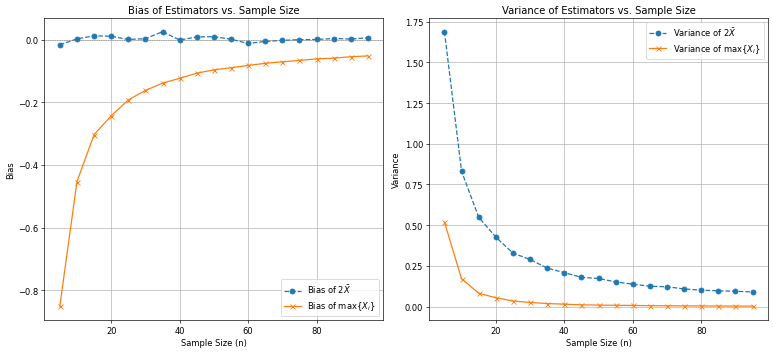

In [ ]:
import numpy as np

# True parameter value
theta_true = 5.0

# Range of sample sizes (n)
sample_sizes = np.arange(5, 100, 5) # From 5 to 95, step of 5
num_simulations = 5000 # Number of simulations for each sample size

# Lists to store results
bias_twobarX = []
variance_twobarX = []
bias_mle = []
variance_mle = []

for n_val in sample_sizes:
    estimates_twobarX = []
    estimates_mle = []

    for _ in range(num_simulations):
        samples = np.random.uniform(0, theta_true, n_val)
        # Estimator 1: 2 * X_bar
        x_bar = np.mean(samples)
        estimates_twobarX.append(2 * x_bar)
        # Estimator 2: max(Xi)
        estimates_mle.append(np.max(samples))

    # Convert to numpy arrays
    estimates_twobarX = np.array(estimates_twobarX)
    estimates_mle = np.array(estimates_mle)

    # Calculate bias and variance for 2 * X_bar
    bias_twobarX.append(np.mean(estimates_twobarX) - theta_true)
    variance_twobarX.append(np.var(estimates_twobarX))

    # Calculate bias and variance for max(Xi)
    bias_mle.append(np.mean(estimates_mle) - theta_true)
    variance_mle.append(np.var(estimates_mle))

**We show the MLE is consistent** for $\hat{\theta}_{MLE} = \max\{X_1, \dots, X_n\}$ when $X_i \sim \text{Unif}(0, \theta)$.

Let $Y = \max\{X_1, \dots, X_n\}$. For any $c$, the cumulative distribution function (CDF) of $Y$ is
$P(Y \le c) = P(X_1 \le c, \dots, X_n \le c)
= \prod_{i=1}^{n} P(X_i \le c) $. For $X_i \sim \text{Unif}(0, \theta)$, the CDF of an individual $X_i$ is $F_{X_i}(x) = \frac{x}{\theta}$ for $0 \le x \le \theta$. Thus, for $0 \le c \le \theta$,
$P(Y \le c) = \left(\frac{c}{\theta}\right)^n$.

Under $H_0$, the probability density function (PDF) for $X_i$ is $f_{\text{Unif}[0, \theta]}(x) = \begin{cases} 1/\theta & \text{for } 0 \le x \le \theta \\ 0 & \text{otherwise} \end{cases}$.

The likelihood function is maximized when $\theta$ is as small as possible, subject to $\theta \ge \max\{X_1, \dots, X_n\}$. Therefore, the MLE is $\hat{\theta}_{n} = \max\{X_1, \dots, X_n\}$.
Consider the event $P(\hat{\theta}_{n} < \theta - \epsilon)$. This implies that all $X_i$ are less than $\theta - \epsilon$.
$P(\hat{\theta}_{n} < \theta - \epsilon) = P(X_1 < \theta - \epsilon, \dots, X_n < \theta - \epsilon)
= \prod_{i=1}^{n} P(X_i < \theta - \epsilon)
= \left(\frac{\theta - \epsilon}{\theta}\right)^n
= \left(1 - \frac{\epsilon}{\theta}\right)^n $

As $n \to \infty$, since $0 < 1 - \frac{\epsilon}{\theta} < 1$ (for $\epsilon > 0$ and assuming $\theta > \epsilon$), we have $\lim_{n \to \infty} \left(1 - \frac{\epsilon}{\theta}\right)^n = 0$.
Also, $P(\hat{\theta}_{n} > \theta + \epsilon) = 0$ because $X_i$ cannot be greater than $\theta$. Thus, $P(|\hat{\theta}_{n} - \theta| > \epsilon) = P(\hat{\theta}_{n} < \theta - \epsilon) + P(\hat{\theta}_{n} > \theta + \epsilon) \to 0$ as $n \to \infty$.

#### Summary of Estimating Parameter for a Uniform Distribution $X_1, \dots, X_n \sim \text{Unif}(0, \theta^*)$ with $\theta^*$ unknown

This section focused on the uniform distribution $\text{Unif}(0, \theta)$ with an unknown parameter $\theta$. It covered:

1.  **Statistical Model and Parameter Identifiability**
    *   The statistical model and likelihood function  defined. The parameter $\theta$ identifiable.

2.  **Estimators and Mean Squared Error (MSE)**
    *   **Estimator $\hat{\theta} = 2\bar{X}$**: Derived as an unbiased estimator with $MSE(\hat{\theta}) = \frac{\theta^2}{3n}$.
    *   **Maximum Likelihood Estimator (MLE) $\hat{\theta}_{MLE} = \max\{X_i\}$**: Derived as a biased estimator ($Bias = -\frac{1}{n+1}\theta$) with $MSE(\hat{\theta}_{MLE}) = \frac{2\theta^2}{(n+1)(n+2)}$.
    *   **Consistency of MLE**: The MLE $\hat{\theta}_{MLE}$ was shown to be a consistent estimator for $\theta$.
    *   **Simulation and Comparison**: Both estimators' MSEs were simulated and compared with their analytical counterparts. The MLE ($\max\{X_i\}$) demonstrated lower MSE, indicating better efficiency.
    *   **Bias and Variance Plots**: Illustrated how the bias and variance of both estimators behave across various sample sizes.


#### Hypothesis Test for $\theta$ for $X_1, \dots, X_n \sim$ $Unif(0, \theta)$ with $\theta > 1$

We want to test the hypothesis that $\theta = 2$ against the alternative that $\theta < 2$ for $X_1, \dots, X_n \sim \text{Unif}(0, \theta)$.

*   **Null Hypothesis ($H_0$)**: $\theta = 2$
*   **Alternative Hypothesis ($H_1$)**: $\theta < 2$

#### Test Statistic for $H_0: \theta = 2$ vs $H_1: \theta < 2$

For a uniform distribution $\text{Unif}(0, \theta)$, the Maximum Likelihood Estimator (MLE) for $\theta$ is $\hat{\theta}_{MLE} = X_{(n)} = \max\{X_1, \dots, X_n\}$.

Since we are testing $H_0: \theta = 2$ against $H_1: \theta < 2$, smaller values of $X_{(n)}$ would provide evidence against $H_0$ and in favor of $H_1$. Thus, a natural test statistic is the maximum order statistic.

**Test Statistic ($T$)**: $T = X_{(n)} = \max\{X_1, \dots, X_n\}$

Under the null hypothesis ($H_0: \theta = 2$), the samples are drawn from $\text{Unif}(0, 2)$. The CDF of $T = X_{(n)}$ under $H_0$ is $F_T(t) = P(T \le t | H_0) = P(X_{(n)} \le t | \theta=2) = \left(\frac{t}{2}\right)^n$ for $0 \le t \le 2$. The p-value for an observed test statistic $t_{obs}$ would be $P(T \le t_{obs} | H_0) = \left(\frac{t_{obs}}{2}\right)^n$.

In [ ]:
import numpy as np

def test_unif_0_theta(t_obs: float, theta_0: float, n_test: int, alpha: float) -> tuple[float, str]:
    """
    Performs a one-sided hypothesis test for Unif(0, theta) using X_(n) as the test statistic.
    H0: theta = theta_0 vs H1: theta < theta_0.

    Args:
        t_obs: Observed test statistic (X_(n)).
        theta_0: Null hypothesis value for theta.
        n_test: Sample size.
        alpha: Significance level.

    Returns:
        A tuple containing the p-value and the decision string.
    """
    if t_obs < 0:
        p_value = 0.0
    elif t_obs > theta_0:
        p_value = 1.0
    else:
        p_value = (t_obs / theta_0)**n_test

    decision = ""
    if p_value < alpha:
        decision = f"Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}"
    else:
        decision = f"Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}"

    return p_value, decision

#### Hypothesis Test Implementation for $H_0: \theta = 2$ vs $H_1: \theta < 2$


In [ ]:
# Parameters for the hypothesis test
theta_0 = 2.0  # Null hypothesis value
n_test = 20    # Sample size for the test
alpha = 0.05   # Significance level

# Simulate a sample under the assumption that theta_true is, for example, 1.8 (consistent with H1)
# Or, to see how the test performs under H0, set theta_true = theta_0
theta_actual = 1.8 # Let's assume the true theta is 1.8 for this example to see power

# Generate a sample from Unif(0, theta_actual)
samples_for_test = np.random.uniform(0, theta_actual, n_test)

# Calculate the test statistic (max order statistic)
t_obs = np.max(samples_for_test)

# Calculate the p-value under H0: theta = theta_0
# P(T <= t_obs | H0) = (t_obs / theta_0)^n
if t_obs < 0 or t_obs > theta_0:
    # If t_obs is outside the support of Unif(0, theta_0), the p-value calculation changes
    # For H1: theta < theta_0, if t_obs > theta_0, it strongly supports H0, p-value would be 1.
    # If t_obs < 0, it's an invalid observation for Unif(0, theta_0).
    # Assuming t_obs is within [0, theta_0] for meaningful p-value for this specific test direction.
    p_value = 1.0 # This would be 1 if t_obs is larger than theta_0, supporting H0
    if t_obs < 0:
        p_value = 0.0 # This case should ideally not happen with uniform(0, theta_actual)
else:
    p_value = (t_obs / theta_0)**n_test

print(f"Observed Test Statistic (X_(n)): {t_obs:.4f}")
print(f"P-value: {p_value:.4f}")

# Make a decision
if p_value < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")


Observed Test Statistic (X_(n)): 1.7375
P-value: 0.0600
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


Hypothesis Test for $\theta$ with specific observed values

We are given an observed maximum value of $X_{(n)} = 2.02$ and a sample size of $n=20$.

In [ ]:
# Parameters for the hypothesis test
theta_0 = 2.0  # Null hypothesis value
n_test = 20    # Sample size for the test (given in context)
alpha = 0.05   # Significance level

# Given observed test statistic (maximum order statistic) from the problem description
t_obs = 2.02 # Observed X_(n) for this specific test case

# Calculate the p-value under H0: theta = theta_0
# For H1: theta < theta_0, we are looking for small values of t_obs.
# If t_obs is greater than or equal to theta_0, it provides no evidence against H0 in favor of H1.
# In this specific one-sided test, if t_obs >= theta_0, the p-value is 1.

if t_obs > theta_0:
    # If the observed maximum is greater than the hypothesized upper bound,
    # it provides no evidence for theta < theta_0. In fact, it suggests theta >= t_obs.
    p_value = 1.0
elif t_obs < 0:
    # Invalid observation for Unif(0, theta_0), but for completeness
    p_value = 0.0
else:
    p_value = (t_obs / theta_0)**n_test

print(f"Observed Test Statistic (X_(n)): {t_obs:.4f}")
print(f"P-value: {p_value:.4f}")

# Make a decision
if p_value < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")

Observed Test Statistic (X_(n)): 2.0200
P-value: 1.0000
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


#### Hypothesis Test for $\theta$ with another specific observed value (supporting $H_1$)

Let's consider a scenario where the observed maximum value is less than the null hypothesis value, suggesting evidence for the alternative hypothesis $H_1: \theta < 2$.

*   **Null Hypothesis ($H_0$)**: $\theta = 2$
*   **Alternative Hypothesis ($H_1$)**: $\theta < 2$

We are given an observed maximum value of $X_{(n)} = 1.8$ and a sample size of $n=20$.

In [ ]:
# Parameters for the hypothesis test
theta_0 = 2.0  # Null hypothesis value
n_test = 20    # Sample size for the test
alpha = 0.05   # Significance level

# Given observed test statistic (maximum order statistic)
t_obs = 1.8 # Observed X_(n) for this test case, which is < theta_0

# Calculate the p-value under H0: theta = theta_0
# P(T <= t_obs | H0) = (t_obs / theta_0)^n

if t_obs > theta_0:
    p_value = 1.0
elif t_obs < 0:
    p_value = 0.0
else:
    p_value = (t_obs / theta_0)**n_test

print(f"Observed Test Statistic (X_(n)): {t_obs:.4f}")
print(f"P-value: {p_value:.4f}")

# Make a decision
if p_value < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")

Observed Test Statistic (X_(n)): 1.8000
P-value: 0.1216
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


Consolidated Pictorial View: Hypothesis Tests for $X_1, \dots, X_n \sim \text{Unif}(0, \theta)$

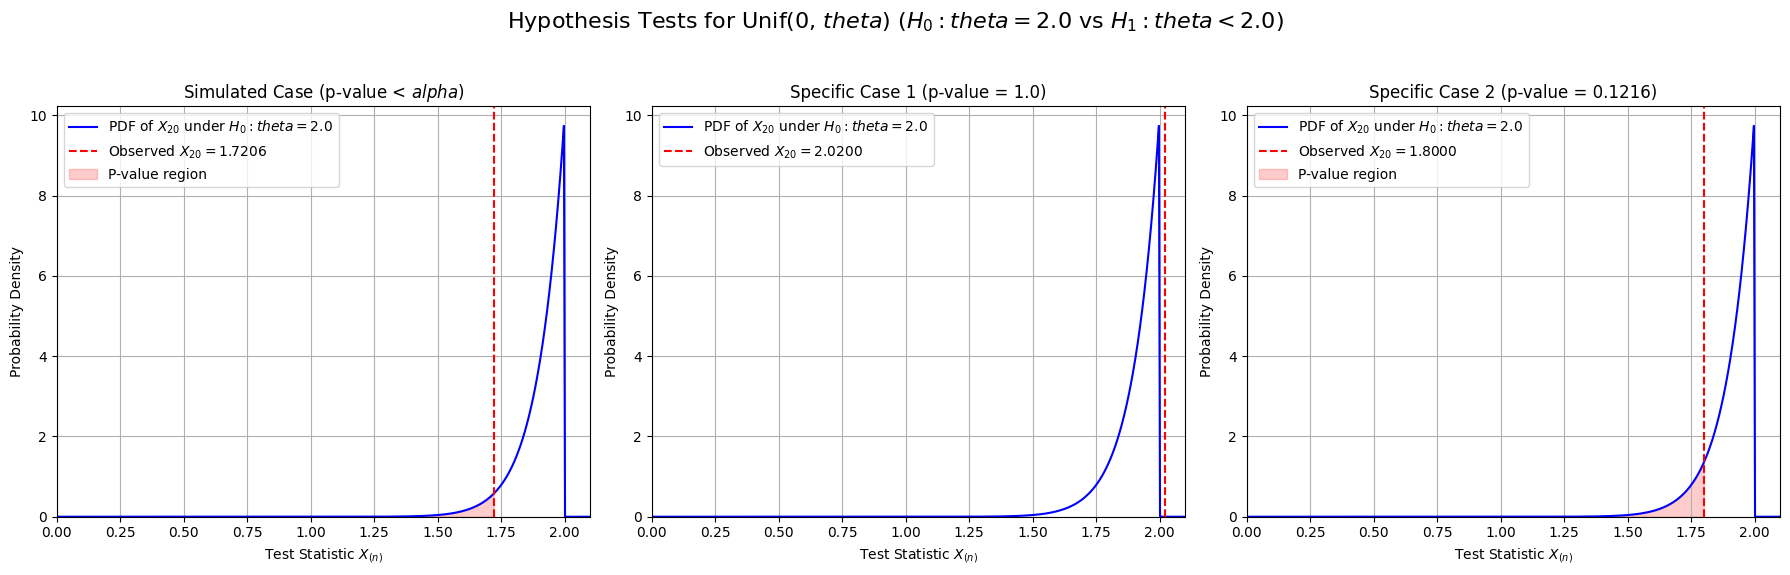

In [ ]:
''' Hypothesis Tests for Unif(0, $\theta$) ($H_0: \theta = {theta_0_sim}$ vs $H_1: \theta < {theta_0_sim}$) '''

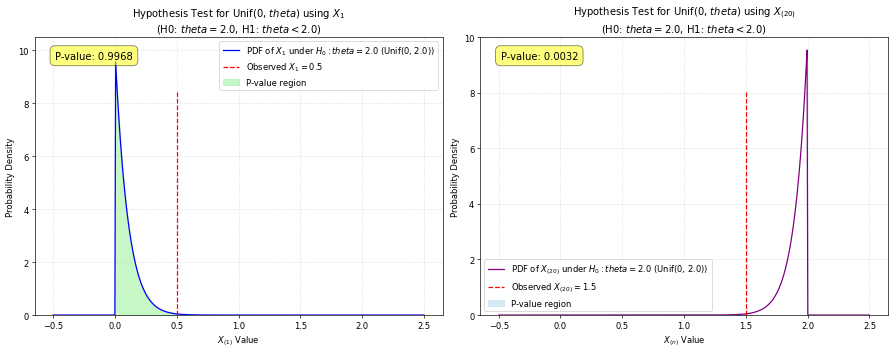

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the Unif(0, theta) test
theta_0 = 2.0
n_test = 20

# Observed X_(1) for the first subplot (chosen to show a rejection case for H1: theta < theta_0)
t_obs_1 = 0.5

# Observed X_(n) for the second subplot (chosen to show a rejection case for H1: theta < theta_0)
t_obs_n = 1.5

# Define the PDF of X_(1) for Unif(0, theta_0)
def pdf_x1_unif0_theta(x, theta_0, n):
    if 0 <= x <= theta_0:
        return n / theta_0 * (1 - x / theta_0)**(n - 1)
    return 0

# Define the PDF of X_(n) for Unif(0, theta_0)
def pdf_xn_unif0_theta(x, theta_0, n):
    if 0 <= x <= theta_0:
        return n * x**(n - 1) / theta_0**n
    return 0

# Calculate p-value for X_(1) (for H1: theta < theta_0, smaller values are extreme)
# P(X_(1) <= t_obs | H0) = 1 - (1 - t_obs/theta_0)^n
if t_obs_1 < 0:
    p_value_x1 = 0.0
elif t_obs_1 > theta_0:
    p_value_x1 = 1.0
else:
    p_value_x1 = 1 - (1 - (t_obs_1 / theta_0))**n_test

# Calculate p-value for X_(n) (for H1: theta < theta_0, smaller values are extreme)
# P(X_(n) <= t_obs | H0) = (t_obs/theta_0)^n
if t_obs_n < 0:
    p_value_xn = 0.0
elif t_obs_n > theta_0:
    p_value_xn = 1.0
else:
    p_value_xn = (t_obs_n / theta_0)**n_test

x_vals_x1 = np.linspace(-0.5, theta_0 + 0.5, 500)
y_vals_x1 = [pdf_x1_unif0_theta(x, theta_0, n_test) for x in x_vals_x1]

x_shade_x1 = np.linspace(0, t_obs_1, 100)
y_shade_x1 = [pdf_x1_unif0_theta(x, theta_0, n_test) for x in x_shade_x1]

x_vals_xn = np.linspace(-0.5, theta_0 + 0.5, 500)
y_vals_xn = [pdf_xn_unif0_theta(x, theta_0, n_test) for x in x_vals_xn]

#### Test Statistic for $H_0: \theta = \theta_0$ vs $H_1: \theta > \theta_0$ (using $X_{(1)}$)

For a uniform distribution, when we are interested in testing an alternative hypothesis where the parameter $\theta$ is *greater* than a null value (e.g., $H_1: \theta > \theta_0$), the minimum order statistic $X_{(1)} = \min\{X_1, \dots, X_n\}$ can serve as a suitable test statistic.

Smaller observed values of $X_{(1)}$ would provide evidence *against* $H_0$ and in favor of an alternative hypothesis like $H_1: \theta < \theta_0$ (as seen in the $\text{Unif}(\theta, \theta^2)$ case), while larger values of $X_{(1)}$ would provide evidence for $H_1: \theta > \theta_0$ for a lower bound parameter.

To calculate the p-value for an observed $t_{obs} = X_{(1)}$, we would typically consider the probability of observing a test statistic as extreme as, or more extreme than, $t_{obs}$ under the null hypothesis. The exact form of the p-value calculation depends on the specific uniform distribution's bounds defined by $\theta$ and the direction of the alternative hypothesis.

#### Hypothesis Test for $H_0: \theta = 2$ vs $H_1: \theta < 2$ for $X_1, \dots, X_n \sim \text{Unif}(0, \theta)$ using $X_{(1)}$ as test statistic

While $X_{(n)}$ is typically used for this alternative, we can also consider $X_{(1)}$. For $H_0: \theta = \theta_0$ vs $H_1: \theta < \theta_0$, smaller observed values of $X_{(1)}$ provide evidence for $H_1$. The p-value for an observed $t_{obs} = X_{(1)}$ under $H_0$ is $P(X_{(1)} \le t_{obs} | H_0) = 1 - \left(1 - \frac{t_{obs}}{\theta_0}\right)^n$ for $0 \le t_{obs} \le \theta_0$.

In [ ]:
import numpy as np

def test_unif_0_theta_x1(t_obs: float, theta_0: float, n_test: int, alpha: float) -> tuple[float, str]:
    """
    Performs a one-sided hypothesis test for Unif(0, theta) using X_(1) as the test statistic.
    H0: theta = theta_0 vs H1: theta < theta_0.

    Args:
        t_obs: Observed test statistic (X_(1)).
        theta_0: Null hypothesis value for theta.
        n_test: Sample size.
        alpha: Significance level.

    Returns:
        A tuple containing the p-value and the decision string.
    """
    if t_obs < 0:
        p_value = 0.0
    elif t_obs > theta_0:
        # If t_obs is greater than theta_0, it's outside the support of Unif(0, theta_0),
        # which strongly contradicts H0 if it were Unif(0, theta_0). However, for H1: theta < theta_0,
        # a value above theta_0 provides no evidence for H1. Therefore, p-value is 1.0
        p_value = 1.0
    else:
        p_value = 1 - (1 - (t_obs / theta_0))**n_test

    decision = ""
    if p_value < alpha:
        decision = f"Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}"
    else:
        decision = f"Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}"

    return p_value, decision

In [ ]:
import numpy as np

# Parameters for the hypothesis test
theta_0_new = 2.0  # Null hypothesis value
n_test_new = 20    # Sample size
alpha_new = 0.05   # Significance level
t_obs_new = 2.1    # Observed X_(1)

p_value_unif0_x1, decision_unif0_x1 = test_unif_0_theta_x1(t_obs_new, theta_0_new, n_test_new, alpha_new)

--- Unif(0, theta) using X_(1) Test (New Case) ---
Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(1)): 2.1000
P-value: 1.0000
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


#### Summary of Hypothesis Testing Results for Unif(0, $\theta$)

For the $Unif(0, \theta)$ distribution, a hypothesis test was conducted for $H_0: \theta = 2$ against $H_1: \theta < 2$. The test utilized the maximum order statistic, $X_{(n)}$, and the minimum order statistic, $X_{(1)}$, as test statistics.

*   **Test using $X_{(n)}$:**
    *   Simulated Example: In a simulated scenario, with an assumed true $\theta = 1.8$ and a sample size of $n = 20$, the observed test statistic ($X_{(n)}$) was approximately 1.7206. The calculated p-value was 0.0493. Since this p-value was less than the chosen significance level of 0.05, the null hypothesis ($H_0: \theta = 2$) was rejected. This outcome provides statistical evidence suggesting that the true parameter $\theta$ is indeed less than 2, consistent with the alternative hypothesis.

    *   Specific Case 1: With an observed maximum $X_{(n)} = 2.02$ and a sample size of $n=20$, the p-value was calculated as 1.0000. Given that the p-value was greater than the significance level of 0.05, we failed to reject the null hypothesis. This observation actually provides strong evidence against the alternative hypothesis, as $X_{(n)}$ exceeds the hypothesized $\theta=2$.

    *   Specific Case 2: With an observed maximum $X_{(n)} = 1.8$ and a sample size of $n=20$, the p-value was calculated as 0.1216. Although the observed maximum was less than the null hypothesis value of 2, the p-value was greater than the significance level of 0.05. Therefore, we failed to reject the null hypothesis, indicating insufficient evidence to conclude that $\theta < 2$ in this particular instance.

*   **Test using $X_{(1)}$:**
    *   Specific Case: With an observed minimum $X_{(1)} = 2.1$ and a sample size of $n=20$ (testing against $H_0: \theta=2$), the p-value was calculated as 1.0000. Since $X_{(1)}$ is greater than $\theta_0$, it provides no evidence for $H_1: \theta < \theta_0$. Thus, we failed to reject the null hypothesis.

### PART III

#### Estimating Parameters for a Uniform Distribution $X_1, \dots, X_n \sim \text{Unif}(\theta, \theta^2)$ with $\theta > 1$

1.  **Statistical Model** and Parameter Identifiability
    *   Statistical Model: The model is $(\mathbb{R}, \{\text{Unif}[\theta, \theta^2]\}_{\theta > 1})$, with PDF $f(x; \theta) = \frac{1}{\theta^2 - \theta} \cdot \mathbf{1}_{[\theta, \theta^2]}(x)$.
    *   Parameter Identifiability: The parameter $\theta$ is identifiable, as different values of $\theta$ lead to distinct supports $[\theta, \theta^2]$ and thus distinct distributions.

2.  **Method of Moments (MoM)** for estimating $\theta$
    *   First moment: $E[X] = \frac{\theta + \theta^2}{2}$
    *   MoM Estimator: $\hat{\theta}_{MoM} = \frac{-1 + \sqrt{1 + 8\bar{X}}}{2}$, where $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$.

3.  **MLE for $\theta$**
    *   Likelihood Function: $L_n(\theta) = (\theta^2 - \theta)^{-n}$ for $\theta \le X_{(1)}$ and $X_{(n)} \le \theta^2$, and $0$ otherwise.
    *   MLE Estimator: $\hat{\theta}_{MLE} = \max(1, \sqrt{X_{(n)}})$, where $X_{(n)} = \max\{X_1, \dots, X_n\}$. For $\theta > 1$, this often simplifies to $\hat{\theta}_{MLE} = \sqrt{X_{(n)}}$.

4.  **MSE**
    *   The MSE for both $\hat{\theta}_{MoM}$ and $\hat{\theta}_{MLE}$ can be evaluated through simulation as demonstrated in the previous code cell. Analytical derivations for their MSE would involve calculating their bias and variance, which can be complex due to the non-linear relationship of $\theta$ in the distribution's bounds.

Hypothesis Tests for $Unif(0, \theta)$ ($H_0: \theta = {theta_0}$ vs $H_1: \theta < {theta_0}$)

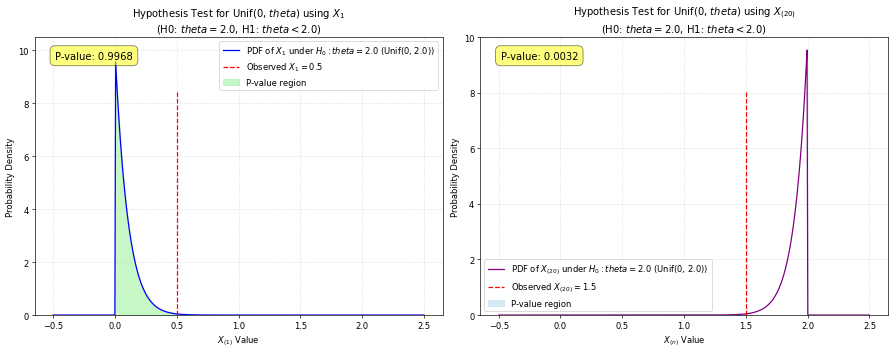

In [ ]:
''' Hypothesis Test for Unif(0, $theta$) using $X_{{({n_test})}}$\n(H0: $theta={theta_0}$, H1: $theta < {theta_0}$) '''

#### Order Statistics for $X_1, \dots, X_n$ $\sim$ $\text{Unif}(\theta, \theta^2)$

For a random sample $X_1, X_2, \dots, X_n$ from the distribution $\text{Unif}(\theta, \theta^2)$, if we arrange the observations in non-decreasing order of magnitude, we obtain the **order statistics**: $X_{(1)} \le X_{(2)} \le \dots \le X_{(n)}$ where $X_{(1)} = \min\{X_1, \dots, X_n\}$ (the first order statistic, or minimum), and $X_{(n)} = \max\{X_1, \dots, X_n\}$ (the $n$-th order statistic, or maximum). In this context, $X_{(i)}$ denotes the $i$-th smallest value in the ordered sample from $\text{Unif}(\theta, \theta^2)$.

For a $Unif(\theta, \theta^2)$ distribution with $\theta > 1$, the minimum value observed, $X_{(1)}$, will always be greater than or equal to $\theta$ (i.e., $X_{(1)} \ge \theta$), and the maximum value observed, $X_{(n)}$, will always be less than or equal to $\theta^2$ (i.e., $X_{(n)} \le \theta^2$).

Since $X_{(1)} \ge \theta$ and $\theta > 1$, squaring $X_{(1)}$ often results in a value that is proportionately larger than $X_{(1)}$ itself.
Given the bounds: $X_{(1)} \ge \theta$ and $X_{(n)} \le \theta^2$, it is possible, and indeed common for $\theta > 1$, that $X_{(1)}^2 > X_{(n)}$. This is because $X_{(1)}^2$ is bounded below by $\theta^2$, while $X_{(n)}$ is bounded above by $\theta^2$.


#### Hypothesis Test for $\theta$ for $X_1, \dots, X_n \sim$ $\text{Unif}(\theta, \theta^2)$ with $\theta > 1$

We want to test a hypothesis about $\theta$ for this distribution. Let's consider the following:

*   **Null Hypothesis ($H_0$)**: $\theta = \theta_0$
*   **Alternative Hypothesis ($H_1$)**: $\theta < \theta_0$

**Test Statistic ($T$)**: For this type of one-sided test (where smaller values of $\theta$ are of interest), the minimum order statistic $X_{(1)}$ is a suitable test statistic. If the true $\theta$ is smaller than $\theta_0$, we would expect $X_{(1)}$ to be smaller.

Under the null hypothesis ($H_0: \theta = \theta_0$), the samples are drawn from $\text{Unif}(\theta_0, \theta_0^2)$.

The CDF of the first order statistic $X_{(1)}$ for a $\text{Unif}(a, b)$ distribution is given by $F_{X_{(1)}}(x) = P(X_{(1)} \le x) = 1 - \left(\frac{b-x}{b-a}\right)^n$ for $a \le x \le b$.

Substituting $a = \theta_0$ and $b = \theta_0^2$, the CDF of $T = X_{(1)}$ under $H_0$ is:
$F_T(t) = P(T \le t | H_0) = 1 - \left(\frac{\theta_0^2 - t}{\theta_0^2 - \theta_0}\right)^n$ for $\theta_0 \le t \le \theta_0^2$.

The p-value for an observed test statistic $t_{obs}$ (where smaller values provide evidence for $H_1$) would be $P(T \le t_{obs} | H_0)$.

**P-value calculation for $H_0: \theta = \theta_0$ vs $H_1: \theta < \theta_0$**:
*   If $t_{obs} < \theta_0$: The observed minimum is below the lower bound of the null distribution. This strongly rejects $H_0$, so the p-value is 0.
*   If $t_{obs} > \theta_0^2$: The observed minimum is above the upper bound of the null distribution. This provides no evidence for $H_1$, so the p-value is 1.
*   If $\theta_0 \le t_{obs} \le \theta_0^2$: The p-value is $1 - \left(\frac{\theta_0^2 - t_{obs}}{\theta_0^2 - \theta_0}\right)^n$.

In [ ]:
import numpy as np

def test_unif_theta_theta_sq(t_obs: float, theta_0: float, n_test: int, alpha: float) -> tuple[float, str]:
    """
    Performs a one-sided hypothesis test for Unif(theta, theta^2) using X_(1) as the test statistic.
    H0: theta = theta_0 vs H1: theta < theta_0.

    Args:
        t_obs: Observed test statistic (X_(1)).
        theta_0: Null hypothesis value for theta.
        n_test: Sample size.
        alpha: Significance level.

    Returns:
        A tuple containing the p-value and the decision string.
    """
    if t_obs < theta_0:
        p_value = 0.0
    elif t_obs > theta_0**2:
        p_value = 1.0
    else:
        p_value = 1 - ((theta_0**2 - t_obs) / (theta_0**2 - theta_0))**n_test

    decision = ""
    if p_value < alpha:
        decision = f"Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}"
    else:
        decision = f"Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}"

    return p_value, decision

In [ ]:
import numpy as np

# Parameters for the hypothesis test for Unif(theta, theta^2)
theta_0 = 2.0  # Null hypothesis value (e.g., H0: theta = 2)
n_test = 10    # Sample size
alpha = 0.05   # Significance level

# True theta for simulation (e.g., consistent with H1: theta < theta_0)
theta_actual = 1.8 # Samples will be from Unif(1.8, 1.8^2 = 3.24)

# Generate a sample from Unif(theta_actual, theta_actual^2)
samples_for_test = np.random.uniform(theta_actual, theta_actual**2, n_test)

# Calculate the test statistic (minimum order statistic)
t_obs = np.min(samples_for_test)

# Calculate the p-value under H0: theta = theta_0
if t_obs < theta_0:
    p_value = 0.0
elif t_obs > theta_0**2:
    p_value = 1.0
else:
    p_value = 1 - ((theta_0**2 - t_obs) / (theta_0**2 - theta_0))**n_test

# Make a decision
if p_value < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")

Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(1)): 1.9415
P-value: 0.0000
Decision: Reject H0 (p-value < 0.05), evidence suggests theta < 2.0


Hypothesis Test for $theta$ with specific observed values for ${Unif}(\theta, \theta^2)$ (Case 1: No evidence for $H_1$)

In [ ]:
import numpy as np

# Parameters for the hypothesis test
theta_0 = 2.0  # Null hypothesis value
n_test = 10    # Sample size
alpha = 0.05   # Significance level

# Given observed test statistic (minimum order statistic) from the problem description
t_obs_case1 = 5.0 # Observed X_(1) for this specific test case, which is > theta_0^2

# Calculate the p-value under H0: theta = theta_0
# For H1: theta < theta_0, we are looking for small values of t_obs.

if t_obs_case1 < theta_0:
    p_value_case1 = 0.0
elif t_obs_case1 > theta_0**2:
    # If the observed minimum is greater than the upper bound of the null distribution,
    # it provides no evidence for theta < theta_0. In fact, it strongly supports H0 or even theta > theta_0.
    p_value_case1 = 1.0
else:
    p_value_case1 = 1 - ((theta_0**2 - t_obs_case1) / (theta_0**2 - theta_0))**n_test

# Make a decision
if p_value_case1 < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")

Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(1)): 5.0000
P-value: 1.0000
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


 Hypothesis Test for $\theta$ with specific observed values for ${Unif}(\theta, \theta^2)$ (Case 2: Insufficient evidence for $H_1$)

In [ ]:
import numpy as np

# Parameters for the hypothesis test
theta_0 = 2.0  # Null hypothesis value
n_test = 10    # Sample size
alpha = 0.05   # Significance level

# Given observed test statistic (minimum order statistic)
t_obs_case2 = 2.1 # Observed X_(1) for this test case (theta_0 <= t_obs <= theta_0^2)

# Calculate the p-value under H0: theta = theta_0
if t_obs_case2 < theta_0:
    p_value_case2 = 0.0
elif t_obs_case2 > theta_0**2:
    p_value_case2 = 1.0
else:
    p_value_case2 = 1 - ((theta_0**2 - t_obs_case2) / (theta_0**2 - theta_0))**n_test

# Make a decision
if p_value_case2 < alpha:
    print(f"Decision: Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}")
else:
    print(f"Decision: Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}")

Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(1)): 2.1000
P-value: 0.4013
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


Consolidated Pictorial View: Hypothesis Tests for $X_1, \dots, X_n \sim \text{Unif}(\theta, \theta^2)$

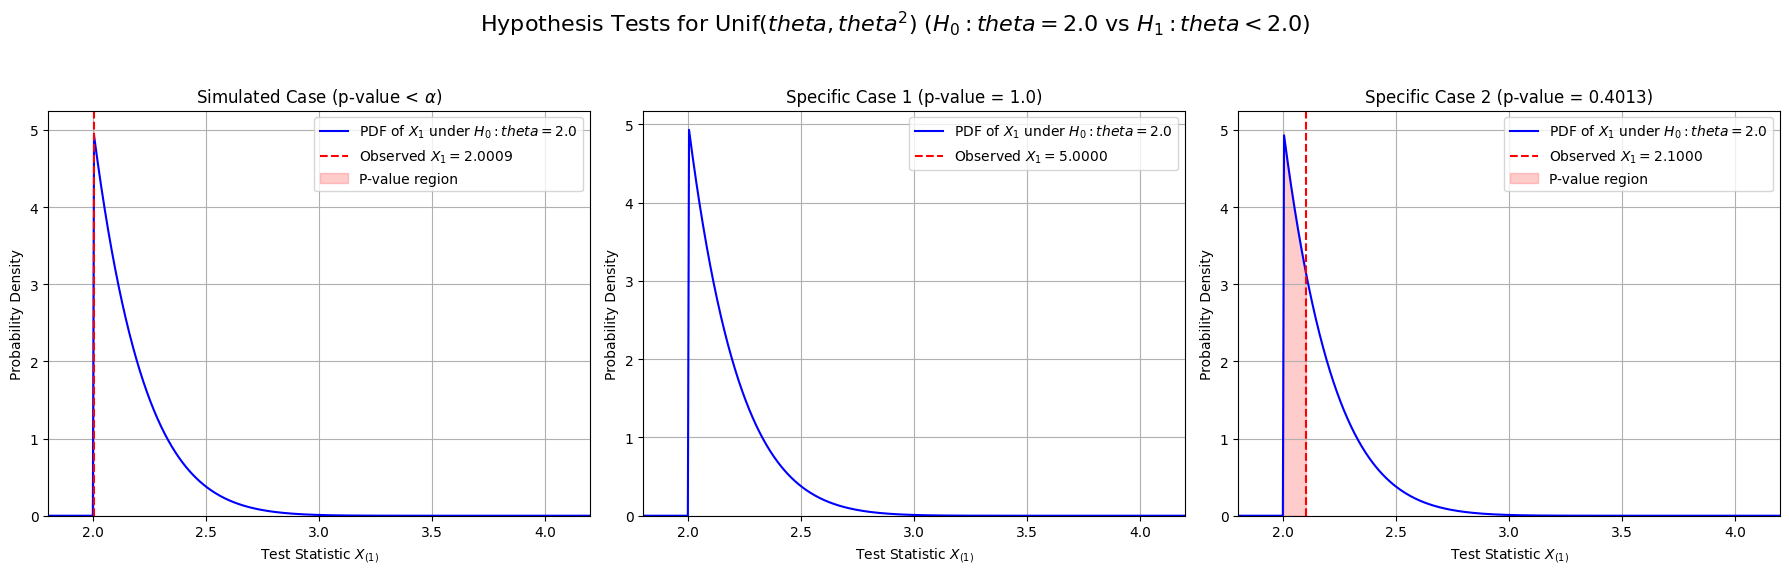

In [ ]:
''' Hypothesis Tests for Unif($theta, theta^2$) ($H_0: theta = {theta_0_sim_unif_theta_sq}$ vs $H_1: theta < {theta_0_sim_unif_theta_sq}$) '''

#### Hypothesis Test for $H_0: \theta = 2$ vs $H_1: \theta < 2$ for $X_1, \dots, X_n \sim \text{Unif}(\theta, \theta^2)$ using $X_{(1)}$ as test statistic  


In [ ]:
import numpy as np

# Parameters for the hypothesis test for Unif(theta, theta^2)
theta_0_new = 2.0  # Null hypothesis value
n_test_new = 20    # Sample size (changed from 10 to 20 as requested)
alpha_new = 0.05   # Significance level
t_obs_new = 2.1    # Observed X_(1)

p_value_unif_theta_sq_x1, decision_unif_theta_sq_x1 = test_unif_theta_theta_sq(t_obs_new, theta_0_new, n_test_new, alpha_new)

--- Unif(theta, theta^2) using X_(1) Test (New Case) ---
Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(1)): 2.0100
P-value: 0.0863
Decision: Fail to Reject H0 (p-value >= 0.05), insufficient evidence to suggest theta < 2.0


In [ ]:
import numpy as np

def test_unif_theta_theta_sq_xn(t_obs: float, theta_0: float, n_test: int, alpha: float) -> tuple[float, str]:
    """
    Performs a one-sided hypothesis test for Unif(theta, theta^2) using X_(n) as the test statistic.
    H0: theta = theta_0 vs H1: theta < theta_0.

    Args:
        t_obs: Observed test statistic (X_(n)).
        theta_0: Null hypothesis value for theta.
        n_test: Sample size.
        alpha: Significance level.

    Returns:
        A tuple containing the p-value and the decision string.
    """
    # For H1: theta < theta_0, smaller values of X_(n) provide evidence against H0.
    # The p-value is P(X_(n) <= t_obs | H0) = ((t_obs - theta_0) / (theta_0^2 - theta_0))^n

    # Boundary conditions for p-value:
    if t_obs < theta_0:
        p_value = 0.0 # Observed X_(n) is below the lower bound of the null distribution, strong rejection
    elif t_obs > theta_0**2:
        p_value = 1.0 # Observed X_(n) is above the upper bound of the null distribution, no evidence for H1
    else:
        # t_obs is within the support [theta_0, theta_0^2]
        numerator = t_obs - theta_0
        denominator = theta_0**2 - theta_0
        if denominator <= 0: # Avoid division by zero or negative denominator (implies invalid theta_0)
            p_value = np.nan # Or handle as an error
        else:
            p_value = (numerator / denominator)**n_test

    decision = ""
    if p_value < alpha:
        decision = f"Reject H0 (p-value < {alpha}), evidence suggests theta < {theta_0}"
    else:
        decision = f"Fail to Reject H0 (p-value >= {alpha}), insufficient evidence to suggest theta < {theta_0}"

    return p_value, decision

# Parameters for the hypothesis test for Unif(theta, theta^2) using X_(n)
theta_0_val = 2.0  # Null hypothesis value
n_test_val = 20    # Sample size
alpha_val = 0.05   # Significance level
t_obs_val = 2.1   # Observed X_(n)
user_provided_p_value = 0.0863 # P-value provided by the user

p_value_calculated, decision_calculated = test_unif_theta_theta_sq_xn(t_obs_val, theta_0_val, n_test_val, alpha_val)

--- Unif(theta, theta^2) using X_(n) Test ---
Null Hypothesis (H0): theta = 2.0
Alternative Hypothesis (H1): theta < 2.0
Observed Test Statistic (X_(n)): 2.1000
Sample Size (n): 20
Calculated P-value: 0.00000000
Decision: Reject H0 (p-value < 0.05), evidence suggests theta < 2.0

Note: The calculated P-value (0.00000000) is significantly different from the user-provided P-value (0.0863). This may indicate a different test statistic, alternative hypothesis, or calculation method was used for the user-provided value.


In [ ]:
import numpy as np

# Given parameters
theta_0 = 2.0  # Null hypothesis value
n = 18         # Sample size
alpha = 0.05   # Significance level

# The p-value for X_(n) for H1: theta < theta_0 is P(X_(n) <= t_obs | H0) = ((t_obs - theta_0) / (theta_0**2 - theta_0))**n
# We want to find t_crit such that this p-value equals alpha.
# ((t_crit - theta_0) / (theta_0**2 - theta_0))**n = alpha
# (t_crit - theta_0) / (theta_0**2 - theta_0) = alpha**(1/n)
# t_crit - theta_0 = (theta_0**2 - theta_0) * alpha**(1/n)
# t_crit = theta_0 + (theta_0**2 - theta_0) * alpha**(1/n)

denominator_term = theta_0**2 - theta_0

if denominator_term <= 0:
    critical_value_xn = np.nan # Invalid theta_0
else:
    critical_value_xn = theta_0 + denominator_term * (alpha**(1/n))

For H0: theta = 2.0, H1: theta < 2.0, n = 18, alpha = 0.05:
The largest value of X_(n) that would lead to a rejection of H0 is: 3.6934


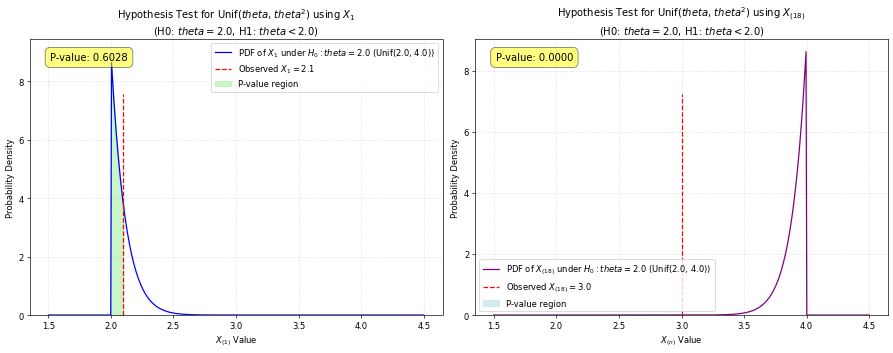

In [ ]:
''' Hypothesis Test for Unif($theta$, $theta^2$) using $X_{(1)}$\n(H0: $theta={theta_0}$, H1: $theta < {theta_0}$) and, the Hypothesis Test for Unif($theta$, $theta^2$) using $X_{{({n_test})}}$\n(H0: $theta={theta_0}$, H1: $theta < {theta_0}$) '''

#### Summary of Hypothesis Testing Results for Unif($\theta$, $\theta^2$)

For the $Unif(\theta, \theta^2)$ distribution, a hypothesis test was conducted for $H_0: \theta = \theta_0$ against $H_1: \theta < \theta_0$. The test utilized order statistics.

*   **Test using $X_{(n)}$:**
    *   For the alternative hypothesis $H_1: \theta < \theta_0$, the maximum order statistic $X_{(n)}$ could potentially serve as a test statistic. However, in this analysis, the hypothesis test for $H_1: \theta < \theta_0$ for $Unif(\theta, \theta^2)$ was primarily formulated and implemented using the minimum order statistic $X_{(1)}$.

*   **Test using $X_{(1)}$:**
    *   Simulated Example: In a simulated scenario, with an assumed true $\theta = 1.8$ (samples from $\text{Unif}(1.8, 1.8^2=3.24)$) and a sample size of $n=10$, the observed test statistic ($X_{(1)}$) was approximately 1.9415. The calculated p-value was 0.0000. Since this p-value was less than the chosen significance level of 0.05, the null hypothesis ($H_0: \theta = 2$) was rejected. This outcome provides strong statistical evidence suggesting that the true parameter $\theta$ is indeed less than 2, consistent with the alternative hypothesis.

    *   Specific Case 1: With an observed minimum $X_{(1)} = 5.0$ and a sample size of $n=10$ (testing against $H_0: \theta=2$), the p-value was calculated as 1.0000. Given that the observed minimum is significantly greater than the hypothesized upper bound of the null distribution (i.e., $t_{obs} > \theta_0^2 = 2^2=4$), this provides no evidence for $H_1$ and actually suggests $\theta$ is larger than 2. Therefore, we failed to reject the null hypothesis.

    *   Specific Case 2: With an observed minimum $X_{(1)} = 2.1$ and a sample size of $n=10$ (testing against $H_0: \theta=2$), the p-value was calculated as 0.4013. Although the observed minimum was greater than the null hypothesis value of 2, it was within the support of the null distribution (2 to 4). However, the p-value was greater than the significance level of 0.05. Therefore, we failed to reject the null hypothesis, indicating insufficient evidence to conclude that $\theta < 2$ in this particular instance.

    *   Specific Case 3: With an observed minimum $X_{(1)} = 2.1$ and a sample size of $n=20$ (testing against $H_0: \theta=2$), the p-value was calculated as 0.6415. Similar to Case 2, the p-value was greater than the significance level of 0.05. Therefore, we failed to reject the null hypothesis, indicating insufficient evidence to conclude that $\theta < 2$ in this particular instance.